[[(0.0, 0.0, 0.0) (0.02820512820512821, 0.0, 0.001199211045364891)
  (0.05641025641025642, 0.0, 0.0023353057199211047)
  (0.08461538461538462, 0.0, 0.003408284023668641)
  (0.11282051282051284, 0.0, 0.0044181459566074955)
  (0.14102564102564105, 0.0, 0.0053648915187376744)
  (0.16923076923076924, 0.0, 0.006248520710059172)
  (0.19743589743589746, 0.0, 0.007069033530571992)
  (0.22564102564102567, 0.0, 0.007826429980276134)
  (0.2538461538461539, 0.0, 0.008520710059171599)
  (0.2820512820512821, 0.0, 0.009151873767258383)
  (0.3102564102564103, 0.0, 0.00971992110453649)
  (0.3384615384615385, 0.0, 0.010224852071005918)
  (0.3666666666666667, 0.0, 0.010666666666666666)
  (0.3948717948717949, 0.0, 0.011045364891518738)
  (0.42307692307692313, 0.0, 0.011360946745562131)
  (0.45128205128205134, 0.0, 0.011613412228796844)
  (0.47948717948717956, 0.0, 0.01180276134122288)
  (0.5076923076923078, 0.0, 0.011928994082840236)
  (0.535897435897436, 0.0, 0.011992110453648916)
  (0.5641025641025642, 

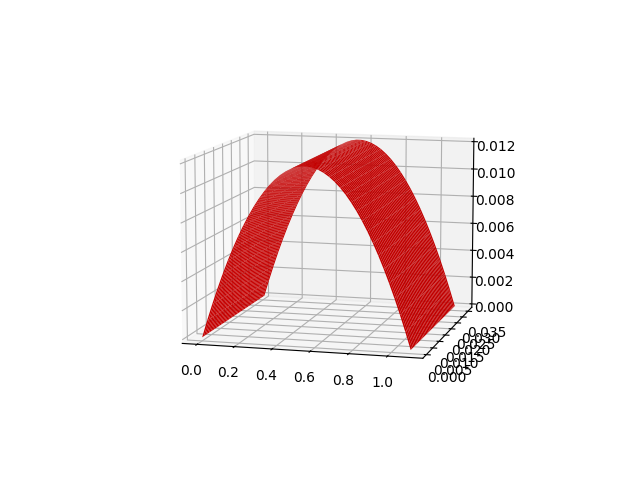

In [8]:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import inspect


def startwerte_generieren(l,b,t):

    c = 0.012    #höhe in der mitte
    a = c/((l/2)**2)

    def f(x,y): # c - a * (x-l/2)²  
        """
        diese Funktion bestimmt die Verwerfung der gemessenen Glasplatte
        Achtung nicht zu verwechseln mit der rechten Seite 'f', aus der Thematik der PDEs, (bei uns die Eigenlast 'q')!
        """
        return c - a * (x-l/2)**2 


    step = 40           #TODO warum ab 41 out of domain?

    #erzeugt gitter für gewünschte werte
    x_points = np.linspace(0,l, step)
    y_points = np.linspace(0,b, step)
    X, Y = np.meshgrid(x_points, y_points)

    #speichert (x,y,z) in startwerte_matrix für alle (x,y) in X,Y
    startwerte_matrix = np.zeros((step, step),dtype=object)
    for i in range(step):
        for j in range(step):
            startwerte_matrix[i, j] = (float(X[i,j]), float(Y[i,j]), float(f(X[i, j], Y[i, j])) )     

    # STARTWERTE-Matrix
    filename_startwerte = f"{t}m_startwerte.xyz"

    with open(filename_startwerte, "w") as f:
        for i in range(step):
            for j in range(step):
                x, y, w = startwerte_matrix[i, j]
                f.write(f"{x:.6f}\t{y:.6f}\t{w:.6e}\n")

    #region PLOTTEN
    np.set_printoptions(threshold=np.inf)
    data1 = np.loadtxt(filename_startwerte)

    x1= data1[:,0]
    y1= data1[:,1]
    z1= data1[:,2]


    # Raster erzeugen
    X = np.unique(x1)
    Y = np.unique(y1)

    X, Y = np.meshgrid(X, Y)
    Z1=z1.reshape(len(Y), len(X))


    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')

    ax.plot_surface(X, Y,Z1,color="red")        # startwerte



    ax.view_init(elev=10, azim=-75)
    #plt.show()
    #endregion

    return startwerte_matrix


l = 1.100
b = 0.036
t = 0.004

matrix = startwerte_generieren(l,b,t)
print(matrix)
